DEMO_J: status=200, content-type=text/plain
BPX_J: status=200, content-type=text/plain
BMX_J: status=200, content-type=text/plain
BPQ_J: status=200, content-type=text/plain

Loaded files:
DEMO: (9254, 46)
BPX: (8704, 21)
BMX: (8704, 21)
BPQ: (6161, 11)

Merged dataset: (8704, 17)

Final adult analysis cohort: (4890, 26)
Regression cohort: (4880, 26)

TABLE 1: Cohort characteristics
                       Variable          Value
                              N           4890
                     Age, years  51.11 ± 17.52
                    BMI, kg/m^2   29.84 ± 7.35
         Mean systolic BP, mmHg 126.57 ± 19.43
        Mean diastolic BP, mmHg  72.88 ± 12.00
           Pulse pressure, mmHg  53.69 ± 17.58
   Mean arterial pressure, mmHg  90.77 ± 12.37
       Relative stiffness index    0.60 ± 0.19
      Apparent compliance index    1.84 ± 0.54
                    Male, n (%)   2382 (48.7%)
                  Female, n (%)   2508 (51.3%)
Hypertension history yes, n (%)   1846 (37.8%)

TAB

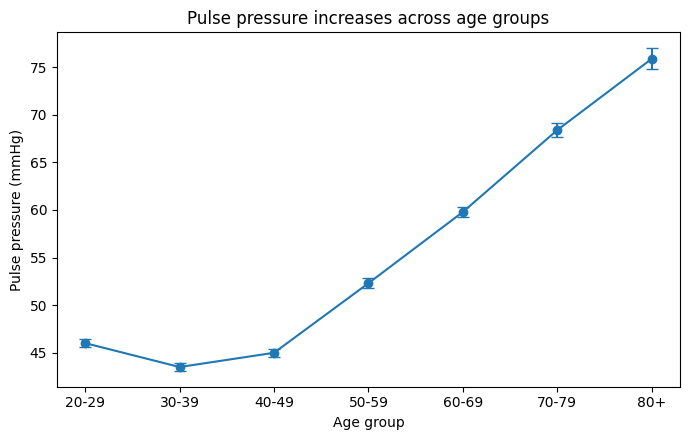

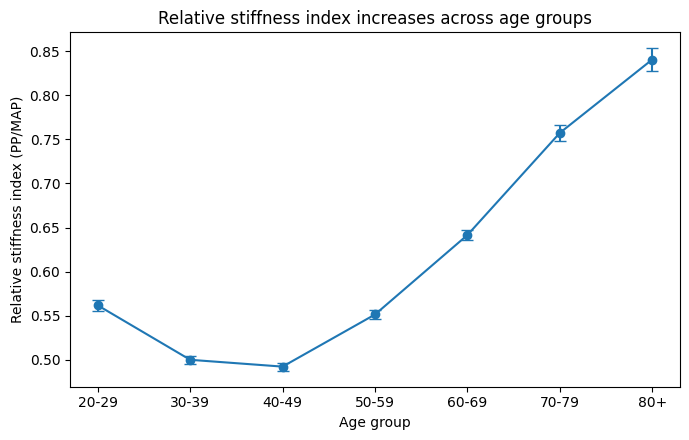

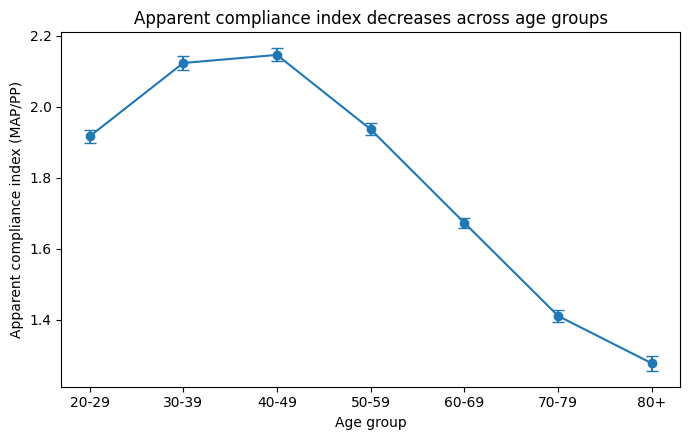


Saved files:
nhanes_arterial_stiffness_cleaned.csv
table1_cohort_characteristics.csv
table2_age_group_trends.csv
table3_regression_summary.csv
table4_age_correlations.csv
figure1_pulse_pressure_by_age.png / .pdf
figure2_stiffness_by_age.png / .pdf
figure3_compliance_by_age.png / .pdf

Paper-ready figure captions:
Figure 1. Mean pulse pressure across age groups in the adult NHANES 2017-2018 cohort. Error bars represent standard error of the mean.
Figure 2. Mean relative stiffness index, calculated as pulse pressure divided by mean arterial pressure, across age groups. Error bars represent standard error of the mean.
Figure 3. Mean apparent compliance index, calculated as mean arterial pressure divided by pulse pressure, across age groups. Error bars represent standard error of the mean.


In [4]:
# ============================================================
# Reduced-Order Modeling of Age-Associated Arterial Stiffness
# Using NHANES 2017-2018 Public Cardiovascular Measurements
#
# Author: Arman Mohammed
# Purpose: Generate analysis tables and figures for manuscript
# ============================================================

# -----------------------------
# 0. Install/import packages
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
import requests
from pathlib import Path

# -----------------------------
# 1. Download NHANES 2017-2018 files
# -----------------------------
# Important:
# These are the actual CDC XPT file URLs.
# The earlier error happened because the old links returned an HTML page,
# not the real SAS transport data file.

urls = {
    "DEMO_J": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.XPT",
    "BPX_J":  "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPX_J.XPT",
    "BMX_J":  "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.XPT",
    "BPQ_J":  "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPQ_J.XPT"
}

headers = {"User-Agent": "Mozilla/5.0"}

def download_file(name, url):
    filename = f"{name}.XPT"
    print(f"Downloading {name}...")
    response = requests.get(url, headers=headers, timeout=60)

    print(f"{name}: status={response.status_code}, content-type={response.headers.get('content-type')}")

    if response.status_code != 200:
        raise ValueError(f"Download failed for {name}. HTTP status: {response.status_code}")

    # Catch HTML error pages early
    first_bytes = response.content[:300].lower()
    if b"<html" in first_bytes or b"<!doctype" in first_bytes:
        raise ValueError(
            f"{name} downloaded as HTML instead of an XPT file. "
            "Try manually downloading the XPT file from the CDC NHANES website and uploading it to Colab."
        )

    Path(filename).write_bytes(response.content)
    return filename

demo_file = download_file("DEMO_J", urls["DEMO_J"])
bpx_file  = download_file("BPX_J", urls["BPX_J"])
bmx_file  = download_file("BMX_J", urls["BMX_J"])
bpq_file  = download_file("BPQ_J", urls["BPQ_J"])

demo = pd.read_sas(demo_file, format="xport")
bpx  = pd.read_sas(bpx_file, format="xport")
bmx  = pd.read_sas(bmx_file, format="xport")
bpq  = pd.read_sas(bpq_file, format="xport")

print("\nLoaded files:")
print("DEMO:", demo.shape)
print("BPX:", bpx.shape)
print("BMX:", bmx.shape)
print("BPQ:", bpq.shape)

# -----------------------------
# 2. Select useful variables
# -----------------------------

demo_keep = demo[
    [
        "SEQN",
        "RIDAGEYR",
        "RIAGENDR",
        "RIDRETH3",
        "WTMEC2YR",
        "SDMVPSU",
        "SDMVSTRA"
    ]
].copy()

bpx_keep = bpx[
    [
        "SEQN",
        "BPXSY1",
        "BPXSY2",
        "BPXSY3",
        "BPXSY4",
        "BPXDI1",
        "BPXDI2",
        "BPXDI3",
        "BPXDI4"
    ]
].copy()

bmx_keep = bmx[
    [
        "SEQN",
        "BMXBMI"
    ]
].copy()

bpq_keep = bpq[
    [
        "SEQN",
        "BPQ020"
    ]
].copy()

# -----------------------------
# 3. Merge files
# -----------------------------

df = demo_keep.merge(bpx_keep, on="SEQN", how="inner")
df = df.merge(bmx_keep, on="SEQN", how="left")
df = df.merge(bpq_keep, on="SEQN", how="left")

print("\nMerged dataset:", df.shape)

# -----------------------------
# 4. Clean blood pressure values
# -----------------------------

sys_cols = ["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"]
dia_cols = ["BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4"]

for col in sys_cols + dia_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df.loc[df[col] <= 0, col] = np.nan

df["SBP_mean"] = df[sys_cols].mean(axis=1, skipna=True)
df["DBP_mean"] = df[dia_cols].mean(axis=1, skipna=True)

# -----------------------------
# 5. Reduced-order vascular indices
# -----------------------------
# Pulse pressure is the pressure amplitude between systolic and diastolic BP.
# MAP is estimated using the standard resting approximation:
# MAP = DBP + PP / 3
#
# Because NHANES does not include stroke volume, these are pressure-derived
# indices, not true directly measured arterial compliance.

df["pulse_pressure"] = df["SBP_mean"] - df["DBP_mean"]
df["MAP"] = df["DBP_mean"] + df["pulse_pressure"] / 3

df["relative_stiffness_index"] = df["pulse_pressure"] / df["MAP"]
df["apparent_compliance_index"] = df["MAP"] / df["pulse_pressure"]

# Labels
df["sex"] = df["RIAGENDR"].map({1: "Male", 2: "Female"})
df["hypertension_history"] = df["BPQ020"].map({1: "Yes", 2: "No"})

# -----------------------------
# 6. Create adult analysis cohort
# -----------------------------

analysis = df.copy()

analysis = analysis[
    (analysis["RIDAGEYR"] >= 20) &
    (analysis["SBP_mean"].notna()) &
    (analysis["DBP_mean"].notna()) &
    (analysis["BMXBMI"].notna()) &
    (analysis["pulse_pressure"] > 10) &
    (analysis["pulse_pressure"] < 120) &
    (analysis["MAP"] > 50) &
    (analysis["MAP"] < 160) &
    (analysis["sex"].notna())
].copy()

analysis_reg = analysis[
    analysis["hypertension_history"].isin(["Yes", "No"])
].copy()

age_bins = [20, 30, 40, 50, 60, 70, 80, 100]
age_labels = ["20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

analysis["age_group"] = pd.cut(
    analysis["RIDAGEYR"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

analysis_reg["age_group"] = pd.cut(
    analysis_reg["RIDAGEYR"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

print("\nFinal adult analysis cohort:", analysis.shape)
print("Regression cohort:", analysis_reg.shape)

# -----------------------------
# 7. Table 1: Cohort characteristics
# -----------------------------

def mean_sd(series):
    return f"{series.mean():.2f} ± {series.std():.2f}"

table1 = pd.DataFrame({
    "Variable": [
        "N",
        "Age, years",
        "BMI, kg/m^2",
        "Mean systolic BP, mmHg",
        "Mean diastolic BP, mmHg",
        "Pulse pressure, mmHg",
        "Mean arterial pressure, mmHg",
        "Relative stiffness index",
        "Apparent compliance index",
        "Male, n (%)",
        "Female, n (%)",
        "Hypertension history yes, n (%)"
    ],
    "Value": [
        str(len(analysis)),
        mean_sd(analysis["RIDAGEYR"]),
        mean_sd(analysis["BMXBMI"]),
        mean_sd(analysis["SBP_mean"]),
        mean_sd(analysis["DBP_mean"]),
        mean_sd(analysis["pulse_pressure"]),
        mean_sd(analysis["MAP"]),
        mean_sd(analysis["relative_stiffness_index"]),
        mean_sd(analysis["apparent_compliance_index"]),
        f"{(analysis['sex'] == 'Male').sum()} ({100 * (analysis['sex'] == 'Male').mean():.1f}%)",
        f"{(analysis['sex'] == 'Female').sum()} ({100 * (analysis['sex'] == 'Female').mean():.1f}%)",
        f"{(analysis['hypertension_history'] == 'Yes').sum()} ({100 * (analysis['hypertension_history'] == 'Yes').mean():.1f}%)"
    ]
})

print("\nTABLE 1: Cohort characteristics")
print(table1.to_string(index=False))

# -----------------------------
# 8. Table 2: Age-group trends
# -----------------------------

table2 = analysis.groupby("age_group", observed=True).agg(
    n=("SEQN", "count"),
    age_mean=("RIDAGEYR", "mean"),
    sbp_mean=("SBP_mean", "mean"),
    dbp_mean=("DBP_mean", "mean"),
    pulse_pressure_mean=("pulse_pressure", "mean"),
    map_mean=("MAP", "mean"),
    stiffness_mean=("relative_stiffness_index", "mean"),
    compliance_mean=("apparent_compliance_index", "mean")
).reset_index()

round_cols = [
    "age_mean",
    "sbp_mean",
    "dbp_mean",
    "pulse_pressure_mean",
    "map_mean",
    "stiffness_mean",
    "compliance_mean"
]

for col in round_cols:
    table2[col] = table2[col].round(3)

print("\nTABLE 2: Age-group trends")
print(table2.to_string(index=False))

# -----------------------------
# 9. Age correlations
# -----------------------------

corr_results = []

for var in ["pulse_pressure", "relative_stiffness_index", "apparent_compliance_index"]:
    temp = analysis[["RIDAGEYR", var]].dropna()
    r, p = stats.pearsonr(temp["RIDAGEYR"], temp[var])
    corr_results.append({
        "Variable": var,
        "Pearson r with age": round(r, 3),
        "p-value": f"{p:.3e}"
    })

corr_table = pd.DataFrame(corr_results)

print("\nAGE CORRELATIONS")
print(corr_table.to_string(index=False))

# -----------------------------
# 10. Regression models
# -----------------------------

model_pp = smf.ols(
    "pulse_pressure ~ RIDAGEYR + BMXBMI + C(sex) + C(hypertension_history)",
    data=analysis_reg
).fit()

model_stiff = smf.ols(
    "relative_stiffness_index ~ RIDAGEYR + BMXBMI + C(sex) + C(hypertension_history)",
    data=analysis_reg
).fit()

model_comp = smf.ols(
    "apparent_compliance_index ~ RIDAGEYR + BMXBMI + C(sex) + C(hypertension_history)",
    data=analysis_reg
).fit()

reg_table = pd.DataFrame({
    "Outcome": [
        "Pulse pressure",
        "Relative stiffness index",
        "Apparent compliance index"
    ],
    "Age coefficient": [
        model_pp.params["RIDAGEYR"],
        model_stiff.params["RIDAGEYR"],
        model_comp.params["RIDAGEYR"]
    ],
    "Age p-value": [
        model_pp.pvalues["RIDAGEYR"],
        model_stiff.pvalues["RIDAGEYR"],
        model_comp.pvalues["RIDAGEYR"]
    ],
    "Model R^2": [
        model_pp.rsquared,
        model_stiff.rsquared,
        model_comp.rsquared
    ],
    "N": [
        int(model_pp.nobs),
        int(model_stiff.nobs),
        int(model_comp.nobs)
    ]
})

reg_table["Age coefficient"] = reg_table["Age coefficient"].round(6)
reg_table["Age p-value"] = reg_table["Age p-value"].apply(lambda x: f"{x:.3e}")
reg_table["Model R^2"] = reg_table["Model R^2"].round(3)

print("\nTABLE 3: Regression summary")
print(reg_table.to_string(index=False))

# Optional: print full model summaries for checking
print("\nFULL MODEL: Pulse pressure")
print(model_pp.summary())

print("\nFULL MODEL: Relative stiffness index")
print(model_stiff.summary())

print("\nFULL MODEL: Apparent compliance index")
print(model_comp.summary())

# -----------------------------
# 11. Figures
# -----------------------------

# Figure 1: Pulse pressure by age group
fig1_data = analysis.groupby("age_group", observed=True)["pulse_pressure"].agg(["mean", "sem"]).reset_index()

plt.figure(figsize=(7, 4.5))
plt.errorbar(
    fig1_data["age_group"].astype(str),
    fig1_data["mean"],
    yerr=fig1_data["sem"],
    marker="o",
    capsize=4
)
plt.xlabel("Age group")
plt.ylabel("Pulse pressure (mmHg)")
plt.title("Pulse pressure increases across age groups")
plt.tight_layout()
plt.savefig("figure1_pulse_pressure_by_age.png", dpi=300)
plt.savefig("figure1_pulse_pressure_by_age.pdf")
plt.show()

# Figure 2: Relative stiffness index by age group
fig2_data = analysis.groupby("age_group", observed=True)["relative_stiffness_index"].agg(["mean", "sem"]).reset_index()

plt.figure(figsize=(7, 4.5))
plt.errorbar(
    fig2_data["age_group"].astype(str),
    fig2_data["mean"],
    yerr=fig2_data["sem"],
    marker="o",
    capsize=4
)
plt.xlabel("Age group")
plt.ylabel("Relative stiffness index (PP/MAP)")
plt.title("Relative stiffness index increases across age groups")
plt.tight_layout()
plt.savefig("figure2_stiffness_by_age.png", dpi=300)
plt.savefig("figure2_stiffness_by_age.pdf")
plt.show()

# Figure 3: Apparent compliance index by age group
fig3_data = analysis.groupby("age_group", observed=True)["apparent_compliance_index"].agg(["mean", "sem"]).reset_index()

plt.figure(figsize=(7, 4.5))
plt.errorbar(
    fig3_data["age_group"].astype(str),
    fig3_data["mean"],
    yerr=fig3_data["sem"],
    marker="o",
    capsize=4
)
plt.xlabel("Age group")
plt.ylabel("Apparent compliance index (MAP/PP)")
plt.title("Apparent compliance index decreases across age groups")
plt.tight_layout()
plt.savefig("figure3_compliance_by_age.png", dpi=300)
plt.savefig("figure3_compliance_by_age.pdf")
plt.show()

# -----------------------------
# 12. Save output files
# -----------------------------

analysis.to_csv("nhanes_arterial_stiffness_cleaned.csv", index=False)
table1.to_csv("table1_cohort_characteristics.csv", index=False)
table2.to_csv("table2_age_group_trends.csv", index=False)
corr_table.to_csv("table4_age_correlations.csv", index=False)
reg_table.to_csv("table3_regression_summary.csv", index=False)

print("\nSaved files:")
print("nhanes_arterial_stiffness_cleaned.csv")
print("table1_cohort_characteristics.csv")
print("table2_age_group_trends.csv")
print("table3_regression_summary.csv")
print("table4_age_correlations.csv")
print("figure1_pulse_pressure_by_age.png / .pdf")
print("figure2_stiffness_by_age.png / .pdf")
print("figure3_compliance_by_age.png / .pdf")

# -----------------------------
# 13. Paper-ready figure captions
# -----------------------------

print("\nPaper-ready figure captions:")
print("Figure 1. Mean pulse pressure across age groups in the adult NHANES 2017-2018 cohort. Error bars represent standard error of the mean.")
print("Figure 2. Mean relative stiffness index, calculated as pulse pressure divided by mean arterial pressure, across age groups. Error bars represent standard error of the mean.")
print("Figure 3. Mean apparent compliance index, calculated as mean arterial pressure divided by pulse pressure, across age groups. Error bars represent standard error of the mean.")

In [5]:
# ============================================================
# Virtual Pulse-Wave Validation Using PWDB Baseline Subjects
# For arterial stiffness manuscript
# Author: Arman Mohammed
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from pathlib import Path
from scipy.io import loadmat
from scipy import stats

# -----------------------------
# 1. Download PWDB baseline files
# -----------------------------

base_url = "https://zenodo.org/records/3339649/files"

files = {
    "haemodynamic_params.mat": f"{base_url}/haemodynamic_params.mat?download=1",
    "pulse_wave_vels.mat": f"{base_url}/pulse_wave_vels.mat?download=1",
    "system_chars.mat": f"{base_url}/system_chars.mat?download=1",
    "pulse_wave_inds.mat": f"{base_url}/pulse_wave_inds.mat?download=1"
}

headers = {"User-Agent": "Mozilla/5.0"}

def download_file(filename, url):
    print(f"Downloading {filename}...")
    response = requests.get(url, headers=headers, timeout=60)
    print(f"{filename}: status={response.status_code}, content-type={response.headers.get('content-type')}")

    if response.status_code != 200:
        raise ValueError(f"Download failed for {filename}")

    first_bytes = response.content[:300].lower()
    if b"<html" in first_bytes or b"<!doctype" in first_bytes:
        raise ValueError(f"{filename} downloaded as HTML, not a MAT file.")

    Path(filename).write_bytes(response.content)
    return filename

for fname, url in files.items():
    download_file(fname, url)

# -----------------------------
# 2. Load MATLAB files
# -----------------------------

def load_mat_file(filename):
    return loadmat(filename, squeeze_me=True, struct_as_record=False)

haemo = load_mat_file("haemodynamic_params.mat")
pwv = load_mat_file("pulse_wave_vels.mat")
system = load_mat_file("system_chars.mat")
pwinds = load_mat_file("pulse_wave_inds.mat")

print("\nLoaded MATLAB files.")

# -----------------------------
# 3. Helper functions to inspect and extract MATLAB variables
# -----------------------------

def is_hidden_key(k):
    return k.startswith("__")

def mat_struct_to_dict(obj):
    """
    Recursively convert MATLAB structs to dictionaries.
    """
    if hasattr(obj, "_fieldnames"):
        result = {}
        for field in obj._fieldnames:
            result[field] = mat_struct_to_dict(getattr(obj, field))
        return result
    elif isinstance(obj, np.ndarray):
        if obj.dtype == object:
            return np.array([mat_struct_to_dict(x) for x in obj])
        else:
            return obj
    else:
        return obj

def clean_mat_dict(mat):
    return {k: mat_struct_to_dict(v) for k, v in mat.items() if not is_hidden_key(k)}

haemo_d = clean_mat_dict(haemo)
pwv_d = clean_mat_dict(pwv)
system_d = clean_mat_dict(system)
pwinds_d = clean_mat_dict(pwinds)

def flatten_dict(d, parent_key="", sep="."):
    """
    Flatten nested dictionaries into path-like keys.
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

flat = {}
for prefix, d in [
    ("haemo", haemo_d),
    ("pwv", pwv_d),
    ("system", system_d),
    ("pwinds", pwinds_d)
]:
    for k, v in flatten_dict(d).items():
        flat[f"{prefix}.{k}"] = v

print("\nAll available variable paths:")
for k, v in flat.items():
    if isinstance(v, np.ndarray):
        print(k, "shape:", v.shape, "dtype:", v.dtype)
    else:
        print(k, "type:", type(v), "value:", v if np.size(v) < 10 else "large")

# -----------------------------
# 4. Extract numeric vectors automatically
# -----------------------------

def to_numeric_vector(x):
    """
    Try converting a MATLAB value into a 1D numeric vector.
    """
    try:
        arr = np.asarray(x).astype(float).squeeze()
        if arr.ndim == 0:
            arr = np.array([float(arr)])
        if arr.ndim == 1 and len(arr) >= 3:
            return arr
        return None
    except Exception:
        return None

numeric_vectors = {}

for k, v in flat.items():
    vec = to_numeric_vector(v)
    if vec is not None:
        numeric_vectors[k] = vec

print("\nNumeric vector candidates:")
for k, v in numeric_vectors.items():
    print(k, "length:", len(v), "values:", np.round(v, 4))

# -----------------------------
# 5. Find likely variables
# -----------------------------

def find_key(possible_terms, required_length=None):
    """
    Find variable path containing any possible term.
    """
    matches = []
    for k, v in numeric_vectors.items():
        k_lower = k.lower()
        if any(term.lower() in k_lower for term in possible_terms):
            if required_length is None or len(v) == required_length:
                matches.append(k)
    return matches

age_keys = find_key(["age"])
print("\nAge keys:", age_keys)

# Try to pick the best age vector
age_key = None
for k in age_keys:
    vals = numeric_vectors[k]
    if len(vals) == 6 and np.nanmin(vals) >= 20 and np.nanmax(vals) <= 80:
        age_key = k
        break

if age_key is None:
    raise ValueError("Could not automatically find the 6-subject age vector. Use printed candidates above.")

ages = numeric_vectors[age_key]
n = len(ages)

print("\nUsing age variable:", age_key)
print("Ages:", ages)

# Find variables of same length as age
same_len = {k: v for k, v in numeric_vectors.items() if len(v) == n}

print("\nSame-length variables:")
for k, v in same_len.items():
    print(k, "=", np.round(v, 5))

# Candidate variable search
candidate_terms = {
    "SBP": ["sbp"],
    "DBP": ["dbp"],
    "MBP": ["mbp", "map"],
    "PP": ["pp", "pulse_pressure"],
    "PWV_cf": ["pwv_cf"],
    "PWV_a": ["pwv_a"],
    "total_arterial_compliance": ["ac", "arterial_compliance"],
    "total_compliance": ["c", "pvc", "compliance"]
}

selected = {}

for label, terms in candidate_terms.items():
    matches = []
    for k, v in same_len.items():
        k_lower = k.lower()
        if any(term.lower() in k_lower for term in terms):
            matches.append(k)
    selected[label] = matches

print("\nCandidate matches:")
for label, matches in selected.items():
    print(label, matches)

# -----------------------------
# 6. Manual-safe extraction logic
# -----------------------------
# The code tries to automatically select meaningful columns.
# If any value looks wrong, use the printed candidate matches to adjust manually.

def choose_first(label):
    matches = selected[label]
    if len(matches) == 0:
        return None, None
    return matches[0], same_len[matches[0]]

sbp_key, sbp = choose_first("SBP")
dbp_key, dbp = choose_first("DBP")
mbp_key, mbp = choose_first("MBP")
pp_key, pp = choose_first("PP")
pwvcf_key, pwv_cf = choose_first("PWV_cf")
pwva_key, pwv_a = choose_first("PWV_a")
ac_key, ac = choose_first("total_arterial_compliance")

# If pulse pressure not directly found but SBP/DBP exist, calculate it
if pp is None and sbp is not None and dbp is not None:
    pp = sbp - dbp
    pp_key = "calculated from SBP - DBP"

# If MBP not directly found but DBP/PP exist, calculate it
if mbp is None and dbp is not None and pp is not None:
    mbp = dbp + pp / 3
    mbp_key = "calculated from DBP + PP/3"

# Build dataframe with available values
pwdb_df = pd.DataFrame({"age": ages})

if sbp is not None:
    pwdb_df["SBP"] = sbp
if dbp is not None:
    pwdb_df["DBP"] = dbp
if mbp is not None:
    pwdb_df["MBP"] = mbp
if pp is not None:
    pwdb_df["PP"] = pp
if pwv_cf is not None:
    pwdb_df["PWV_cf"] = pwv_cf
if pwv_a is not None:
    pwdb_df["PWV_a"] = pwv_a
if ac is not None:
    pwdb_df["total_arterial_compliance"] = ac

# Derived indices matching NHANES
if "PP" in pwdb_df.columns and "MBP" in pwdb_df.columns:
    pwdb_df["relative_stiffness_index"] = pwdb_df["PP"] / pwdb_df["MBP"]
    pwdb_df["apparent_compliance_index"] = pwdb_df["MBP"] / pwdb_df["PP"]

print("\nSelected variable sources:")
print("Age:", age_key)
print("SBP:", sbp_key)
print("DBP:", dbp_key)
print("MBP:", mbp_key)
print("PP:", pp_key)
print("PWV_cf:", pwvcf_key)
print("PWV_a:", pwva_key)
print("Total arterial compliance:", ac_key)

print("\nPWDB validation table:")
print(pwdb_df.round(5).to_string(index=False))

# -----------------------------
# 7. Correlations with age
# -----------------------------

corr_rows = []

for col in pwdb_df.columns:
    if col == "age":
        continue
    temp = pwdb_df[["age", col]].dropna()
    if len(temp) >= 3:
        r, p = stats.pearsonr(temp["age"], temp[col])
        corr_rows.append({
            "Variable": col,
            "Pearson r with age": round(r, 3),
            "p-value": f"{p:.3e}"
        })

pwdb_corr = pd.DataFrame(corr_rows)

print("\nPWDB age correlations:")
print(pwdb_corr.to_string(index=False))

# -----------------------------
# 8. Figures
# -----------------------------

# Figure 4: PWDB pulse pressure and PWV/compliance trends
if "PP" in pwdb_df.columns:
    plt.figure(figsize=(7, 4.5))
    plt.plot(pwdb_df["age"], pwdb_df["PP"], marker="o")
    plt.xlabel("Virtual subject age (years)")
    plt.ylabel("Pulse pressure (mmHg)")
    plt.title("PWDB pulse pressure across baseline virtual ages")
    plt.tight_layout()
    plt.savefig("figure4_pwdb_pulse_pressure_by_age.png", dpi=300)
    plt.savefig("figure4_pwdb_pulse_pressure_by_age.pdf")
    plt.show()

if "PWV_cf" in pwdb_df.columns:
    plt.figure(figsize=(7, 4.5))
    plt.plot(pwdb_df["age"], pwdb_df["PWV_cf"], marker="o")
    plt.xlabel("Virtual subject age (years)")
    plt.ylabel("Carotid-femoral PWV (m/s)")
    plt.title("PWDB carotid-femoral pulse wave velocity across baseline virtual ages")
    plt.tight_layout()
    plt.savefig("figure5_pwdb_pwv_by_age.png", dpi=300)
    plt.savefig("figure5_pwdb_pwv_by_age.pdf")
    plt.show()

if "total_arterial_compliance" in pwdb_df.columns:
    plt.figure(figsize=(7, 4.5))
    plt.plot(pwdb_df["age"], pwdb_df["total_arterial_compliance"], marker="o")
    plt.xlabel("Virtual subject age (years)")
    plt.ylabel("Total arterial compliance")
    plt.title("PWDB total arterial compliance across baseline virtual ages")
    plt.tight_layout()
    plt.savefig("figure6_pwdb_compliance_by_age.png", dpi=300)
    plt.savefig("figure6_pwdb_compliance_by_age.pdf")
    plt.show()

if "relative_stiffness_index" in pwdb_df.columns:
    plt.figure(figsize=(7, 4.5))
    plt.plot(pwdb_df["age"], pwdb_df["relative_stiffness_index"], marker="o")
    plt.xlabel("Virtual subject age (years)")
    plt.ylabel("Relative stiffness index (PP/MBP)")
    plt.title("PWDB pressure-derived stiffness index across baseline virtual ages")
    plt.tight_layout()
    plt.savefig("figure7_pwdb_relative_stiffness_by_age.png", dpi=300)
    plt.savefig("figure7_pwdb_relative_stiffness_by_age.pdf")
    plt.show()

# -----------------------------
# 9. Save tables
# -----------------------------

pwdb_df.to_csv("table4_pwdb_validation_table.csv", index=False)
pwdb_corr.to_csv("table5_pwdb_age_correlations.csv", index=False)

print("\nSaved files:")
print("table4_pwdb_validation_table.csv")
print("table5_pwdb_age_correlations.csv")
print("figure4_pwdb_pulse_pressure_by_age.png / .pdf, if PP found")
print("figure5_pwdb_pwv_by_age.png / .pdf, if PWV_cf found")
print("figure6_pwdb_compliance_by_age.png / .pdf, if compliance found")
print("figure7_pwdb_relative_stiffness_by_age.png / .pdf, if RSI found")

print("\nPaper-ready caption ideas:")
print("Figure 4. Pulse pressure across PWDB baseline virtual subjects aged 25 to 75 years.")
print("Figure 5. Carotid-femoral pulse wave velocity across PWDB baseline virtual subjects aged 25 to 75 years.")
print("Figure 6. Total arterial compliance across PWDB baseline virtual subjects aged 25 to 75 years.")
print("Figure 7. Pressure-derived relative stiffness index across PWDB baseline virtual subjects aged 25 to 75 years.")

haemodynamic_params.mat: status=403, content-type=text/html; charset=utf-8


ValueError: Download failed for haemodynamic_params.mat

In [6]:
# ============================================================
# Virtual Pulse-Wave Validation Using PWDB Baseline CSV Data
# For arterial stiffness manuscript
# Author: Arman Mohammed
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf

# -----------------------------
# 1. Download PWDB haemodynamic CSV file
# -----------------------------

filename = "pwdb_haemod_params.csv"

possible_urls = [
    "https://zenodo.org/record/3339560/files/pwdb_haemod_params.csv?download=1",
    "https://zenodo.org/records/3339560/files/pwdb_haemod_params.csv?download=1",
]

headers = {"User-Agent": "Mozilla/5.0"}

downloaded = False

for url in possible_urls:
    print("Trying:", url)
    response = requests.get(url, headers=headers, timeout=60, allow_redirects=True)
    print("Status:", response.status_code)
    print("Content-type:", response.headers.get("content-type"))

    first_bytes = response.content[:300].lower()
    is_html = b"<html" in first_bytes or b"<!doctype" in first_bytes

    if response.status_code == 200 and not is_html and len(response.content) > 100:
        Path(filename).write_bytes(response.content)
        print("Downloaded PWDB CSV successfully.")
        downloaded = True
        break

if not downloaded:
    raise ValueError("Could not download pwdb_haemod_params.csv from Zenodo.")

# -----------------------------
# 2. Load PWDB CSV
# -----------------------------

pwdb = pd.read_csv(filename)

# Clean column names
pwdb.columns = [str(c).strip() for c in pwdb.columns]

print("\nPWDB raw shape:", pwdb.shape)
print("\nPWDB columns:")
print(list(pwdb.columns))

print("\nFirst rows:")
print(pwdb.head().to_string(index=False))

# -----------------------------
# 3. Helper function to choose columns
# -----------------------------
# The PWDB documentation says the haemodynamic file includes:
# age, SBP, DBP, MBP, PP, PWV_a, PWV_cf, and related variables.
# Some pressure variables can appear with site suffixes:
# a = aortic root, b = brachial artery, f = finger.
# For comparison with NHANES cuff blood pressure, brachial values are preferred if present.

def choose_column(priority_names, contains_terms=None):
    """
    Select a column from priority names first, then by partial matching.
    """
    cols = list(pwdb.columns)
    lower_map = {c.lower(): c for c in cols}

    # Exact priority search
    for name in priority_names:
        if name.lower() in lower_map:
            return lower_map[name.lower()]

    # Contains search
    if contains_terms:
        for c in cols:
            c_lower = c.lower()
            if all(term.lower() in c_lower for term in contains_terms):
                return c

    return None

age_col = choose_column(["age"], ["age"])

sbp_col = choose_column(["SBP_b", "SBP", "SBP_a", "SBP_f"], ["sbp"])
dbp_col = choose_column(["DBP_b", "DBP", "DBP_a", "DBP_f"], ["dbp"])
mbp_col = choose_column(["MBP_b", "MBP", "MBP_a", "MBP_f", "MAP_b", "MAP"], ["mbp"])
pp_col  = choose_column(["PP_b", "PP", "PP_a", "PP_f"], ["pp"])

pwv_cf_col = choose_column(["PWV_cf", "cfPWV", "PWVcf"], ["pwv", "cf"])
pwv_a_col  = choose_column(["PWV_a", "aPWV", "PWVa"], ["pwv", "a"])

sv_col = choose_column(["SV"], ["sv"])
hr_col = choose_column(["HR"], ["hr"])

print("\nSelected columns:")
print("Age:", age_col)
print("SBP:", sbp_col)
print("DBP:", dbp_col)
print("MBP:", mbp_col)
print("PP:", pp_col)
print("PWV_cf:", pwv_cf_col)
print("PWV_a:", pwv_a_col)
print("SV:", sv_col)
print("HR:", hr_col)

if age_col is None:
    raise ValueError("Could not find age column.")

# -----------------------------
# 4. Build validation dataframe
# -----------------------------

validation = pd.DataFrame()
validation["age"] = pd.to_numeric(pwdb[age_col], errors="coerce")

if sbp_col is not None:
    validation["SBP"] = pd.to_numeric(pwdb[sbp_col], errors="coerce")

if dbp_col is not None:
    validation["DBP"] = pd.to_numeric(pwdb[dbp_col], errors="coerce")

if mbp_col is not None:
    validation["MBP"] = pd.to_numeric(pwdb[mbp_col], errors="coerce")

if pp_col is not None:
    validation["PP"] = pd.to_numeric(pwdb[pp_col], errors="coerce")

if pwv_cf_col is not None:
    validation["PWV_cf"] = pd.to_numeric(pwdb[pwv_cf_col], errors="coerce")

if pwv_a_col is not None:
    validation["PWV_a"] = pd.to_numeric(pwdb[pwv_a_col], errors="coerce")

if sv_col is not None:
    validation["SV"] = pd.to_numeric(pwdb[sv_col], errors="coerce")

if hr_col is not None:
    validation["HR"] = pd.to_numeric(pwdb[hr_col], errors="coerce")

# Calculate PP if not directly available
if "PP" not in validation.columns and "SBP" in validation.columns and "DBP" in validation.columns:
    validation["PP"] = validation["SBP"] - validation["DBP"]

# Calculate MBP if not directly available
if "MBP" not in validation.columns and "DBP" in validation.columns and "PP" in validation.columns:
    validation["MBP"] = validation["DBP"] + validation["PP"] / 3

# Match NHANES pressure-derived indices
if "PP" in validation.columns and "MBP" in validation.columns:
    validation["relative_stiffness_index"] = validation["PP"] / validation["MBP"]
    validation["apparent_compliance_index"] = validation["MBP"] / validation["PP"]

# Keep clean rows
validation = validation.dropna(subset=["age"]).copy()
validation = validation.sort_values("age").reset_index(drop=True)

print("\nPWDB validation table:")
print(validation.round(5).to_string(index=False))

# -----------------------------
# 5. Age correlations in PWDB
# -----------------------------

corr_rows = []

for col in validation.columns:
    if col == "age":
        continue

    temp = validation[["age", col]].dropna()

    if len(temp) >= 3:
        r, p = stats.pearsonr(temp["age"], temp[col])
        corr_rows.append({
            "Variable": col,
            "Pearson r with age": round(r, 3),
            "p-value": f"{p:.3e}",
            "Direction": "increases with age" if r > 0 else "decreases with age"
        })

pwdb_corr = pd.DataFrame(corr_rows)

print("\nPWDB age correlations:")
print(pwdb_corr.to_string(index=False))

# -----------------------------
# 6. Simple linear slopes
# -----------------------------

slope_rows = []

for col in validation.columns:
    if col == "age":
        continue

    temp = validation[["age", col]].dropna()

    if len(temp) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(temp["age"], temp[col])
        slope_rows.append({
            "Variable": col,
            "Slope per year": slope,
            "Intercept": intercept,
            "R-squared": r_value**2,
            "p-value": p_value
        })

slope_table = pd.DataFrame(slope_rows)

if len(slope_table) > 0:
    slope_table["Slope per year"] = slope_table["Slope per year"].round(6)
    slope_table["Intercept"] = slope_table["Intercept"].round(6)
    slope_table["R-squared"] = slope_table["R-squared"].round(3)
    slope_table["p-value"] = slope_table["p-value"].apply(lambda x: f"{x:.3e}")

print("\nPWDB linear trend table:")
print(slope_table.to_string(index=False))

# -----------------------------
# 7. Directional agreement with NHANES
# -----------------------------
# NHANES findings:
# Age increased pulse pressure.
# Age increased relative stiffness index.
# Age decreased apparent compliance index.

agreement_rows = []

def add_agreement(variable_name, expected_direction):
    if variable_name in validation.columns:
        temp = validation[["age", variable_name]].dropna()
        if len(temp) >= 3:
            r, p = stats.pearsonr(temp["age"], temp[variable_name])
            observed_direction = "increases" if r > 0 else "decreases"
            agreement = "Yes" if observed_direction == expected_direction else "No"
            agreement_rows.append({
                "Variable": variable_name,
                "NHANES expected direction": expected_direction,
                "PWDB observed direction": observed_direction,
                "Directional agreement": agreement,
                "PWDB r": round(r, 3),
                "PWDB p-value": f"{p:.3e}"
            })

add_agreement("PP", "increases")
add_agreement("relative_stiffness_index", "increases")
add_agreement("apparent_compliance_index", "decreases")

# PWV_cf is an external biomechanical stiffness measure,
# so the expected direction is also increase with age.
add_agreement("PWV_cf", "increases")
add_agreement("PWV_a", "increases")

agreement_table = pd.DataFrame(agreement_rows)

print("\nDirectional agreement table:")
print(agreement_table.to_string(index=False))

# -----------------------------
# 8. Figures
# -----------------------------

def plot_by_age(y_col, y_label, title, filename_prefix):
    if y_col not in validation.columns:
        print(f"Skipping {y_col}: column not found.")
        return

    temp = validation[["age", y_col]].dropna()

    plt.figure(figsize=(7, 4.5))
    plt.plot(temp["age"], temp[y_col], marker="o")
    plt.xlabel("Virtual subject age (years)")
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{filename_prefix}.png", dpi=300)
    plt.savefig(f"{filename_prefix}.pdf")
    plt.show()

plot_by_age(
    "PP",
    "Pulse pressure (mmHg)",
    "PWDB pulse pressure across baseline virtual ages",
    "figure4_pwdb_pulse_pressure_by_age"
)

plot_by_age(
    "PWV_cf",
    "Carotid-femoral pulse wave velocity (m/s)",
    "PWDB carotid-femoral pulse wave velocity across baseline virtual ages",
    "figure5_pwdb_pwv_cf_by_age"
)

plot_by_age(
    "relative_stiffness_index",
    "Relative stiffness index (PP/MBP)",
    "PWDB pressure-derived stiffness index across baseline virtual ages",
    "figure6_pwdb_relative_stiffness_by_age"
)

plot_by_age(
    "apparent_compliance_index",
    "Apparent compliance index (MBP/PP)",
    "PWDB apparent compliance index across baseline virtual ages",
    "figure7_pwdb_apparent_compliance_by_age"
)

# -----------------------------
# 9. Save output tables
# -----------------------------

validation.to_csv("table4_pwdb_validation_table.csv", index=False)
pwdb_corr.to_csv("table5_pwdb_age_correlations.csv", index=False)
slope_table.to_csv("table6_pwdb_linear_trends.csv", index=False)
agreement_table.to_csv("table7_directional_agreement.csv", index=False)

print("\nSaved files:")
print("table4_pwdb_validation_table.csv")
print("table5_pwdb_age_correlations.csv")
print("table6_pwdb_linear_trends.csv")
print("table7_directional_agreement.csv")
print("figure4_pwdb_pulse_pressure_by_age.png / .pdf")
print("figure5_pwdb_pwv_cf_by_age.png / .pdf")
print("figure6_pwdb_relative_stiffness_by_age.png / .pdf")
print("figure7_pwdb_apparent_compliance_by_age.png / .pdf")

# -----------------------------
# 10. Paper-ready captions
# -----------------------------

print("\nPaper-ready figure captions:")
print("Figure 4. Pulse pressure across PWDB baseline virtual subjects aged 25 to 75 years.")
print("Figure 5. Carotid-femoral pulse wave velocity across PWDB baseline virtual subjects aged 25 to 75 years.")
print("Figure 6. Pressure-derived relative stiffness index across PWDB baseline virtual subjects aged 25 to 75 years.")
print("Figure 7. Apparent compliance index across PWDB baseline virtual subjects aged 25 to 75 years.")

Trying: https://zenodo.org/record/3339560/files/pwdb_haemod_params.csv?download=1
Status: 403
Content-type: text/html; charset=utf-8
Trying: https://zenodo.org/records/3339560/files/pwdb_haemod_params.csv?download=1
Status: 403
Content-type: text/html; charset=utf-8


ValueError: Could not download pwdb_haemod_params.csv from Zenodo.

PWDB validation table:
 age  SBP_brachial  DBP_brachial  MBP_brachial  PP_brachial  PWV_aortic  PWV_carotid_femoral  augmentation_index  stroke_volume  heart_rate  cardiac_output  relative_stiffness_index  apparent_compliance_index
  25        112.84        73.181        89.751       39.658      5.8698               6.3210              6.7246         66.306      72.816          4.8281                   0.44187                    2.26312
  35        116.47        75.810        93.290       40.661      6.3970               6.8645             11.1290         64.302      76.726          4.9337                   0.43586                    2.29434
  45        120.55        77.148        96.542       43.400      7.1579               7.6447             18.1680         61.702      77.720          4.7955                   0.44955                    2.22447
  55        121.23        75.366        96.610       45.861      7.9684               8.4697             26.8590         59.377      77.320  

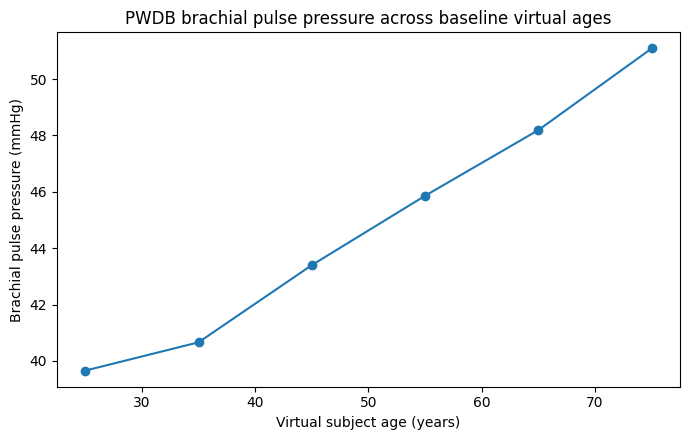

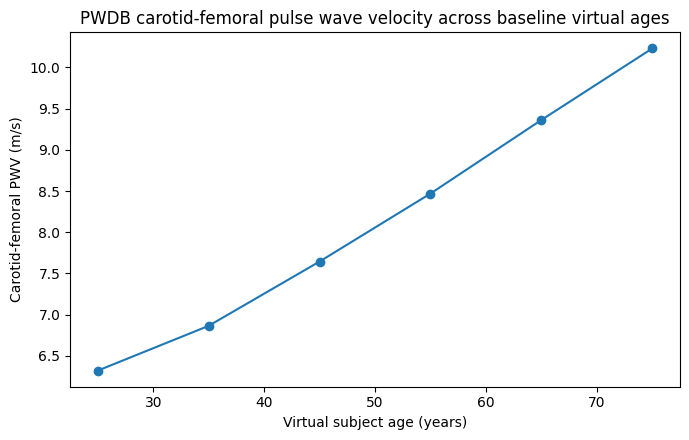

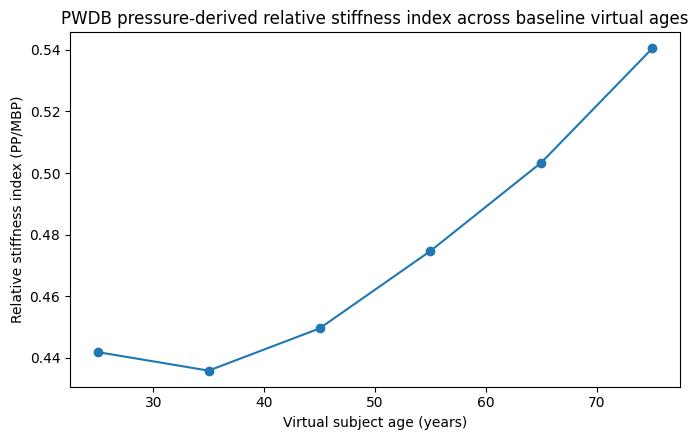

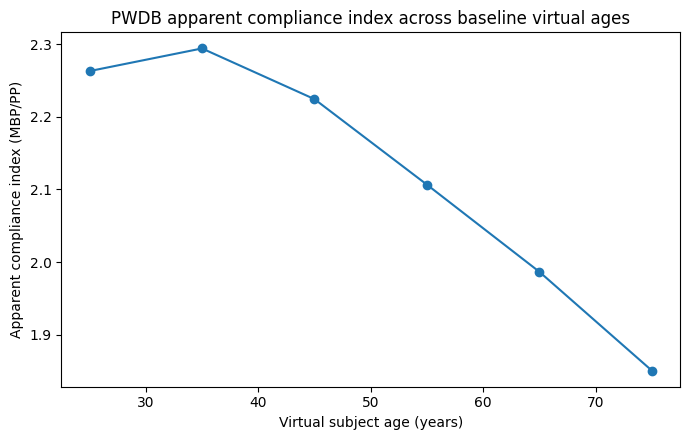


Saved files:
table4_pwdb_validation_table.csv
table5_pwdb_age_correlations.csv
table6_pwdb_linear_trends.csv
table7_directional_agreement.csv
figure4_pwdb_pulse_pressure_by_age.png / .pdf
figure5_pwdb_pwv_cf_by_age.png / .pdf
figure6_pwdb_relative_stiffness_by_age.png / .pdf
figure7_pwdb_apparent_compliance_by_age.png / .pdf

Paper-ready figure captions:
Figure 4. Brachial pulse pressure across PWDB baseline virtual subjects aged 25 to 75 years.
Figure 5. Carotid-femoral pulse wave velocity across PWDB baseline virtual subjects aged 25 to 75 years.
Figure 6. Pressure-derived relative stiffness index across PWDB baseline virtual subjects aged 25 to 75 years.
Figure 7. Apparent compliance index across PWDB baseline virtual subjects aged 25 to 75 years.


In [7]:
# ============================================================
# Virtual Pulse-Wave Validation Using PWDB Baseline Data
# For arterial stiffness manuscript
# Author: Arman Mohammed
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from io import StringIO

# -----------------------------
# 1. Embedded PWDB baseline data
# -----------------------------
# Source file: pwdb_haemod_params.csv from PWDB baseline subjects aged 25-75.
# Embedded here to avoid Colab/Zenodo download issues.

csv_text = """Subject Number, age [years], HR [bpm], SV [ml], CO [l/min], LVET [ms], dp/dt [mmHg/s], PFT [ms], RFV [ml], SBP_a [mmHg], DBP_a [mmHg], MAP_a [mmHg], PP_a [mmHg], SBP_b [mmHg], DBP_b [mmHg], MBP_b [mmHg], PP_b [mmHg], PP_amp [ratio], AP [mmHg], AIx [%], Tr [ms], PWV_a [m/s], PWV_cf [m/s], PWV_br [m/s], PWV_fa [m/s], dia_asca [mm], dia_dta [mm], dia_abda [mm], dia_car [mm], Len [mm], drop fin [mmHg], drop ankle [mmHg], SVR [10^6 Pa s / m3]
1,25,72.816,66.306,4.8281,282,570.44,80,0.74833,100.03,75.592,89.857,24.437,112.84,73.181,89.751,39.658,1.6229,1.6433,6.7246,124,5.8698,6.321,8.9292,8.8127,36.718,24.485,14.575,8.7349,80,2.3309,7.2473,148.89
2,35,76.726,64.302,4.9337,282,556.23,80,0.71723,104.4,78.3,93.454,26.102,116.47,75.81,93.29,40.661,1.5578,2.9048,11.129,116,6.397,6.8645,9.5108,9.2978,37.882,25.248,15.012,9.0329,86.403,2.4243,7.617,151.53
3,45,77.72,61.702,4.7955,282,562.32,80,0.71772,109.78,79.668,96.678,30.113,120.55,77.148,96.542,43.4,1.4412,5.471,18.168,106,7.1579,7.6447,10.313,9.9966,39.001,25.972,15.421,9.3127,92.806,2.3556,7.5366,161.28
4,55,77.32,59.377,4.591,282,575.16,80,0.71622,112.39,77.858,96.772,34.534,121.23,75.366,96.61,45.861,1.328,9.2754,26.859,94,7.9684,8.4697,11.105,10.724,40.125,26.707,15.833,9.5901,99.209,2.2269,7.3367,168.62
5,65,76.531,56.838,4.3498,282,576.36,80,0.71699,114.05,74.92,95.81,39.125,120.71,72.519,95.729,48.191,1.2317,13.92,35.578,84,8.7971,9.3628,11.923,11.507,41.271,27.462,16.26,9.8733,105.61,2.1797,7.024,176.2
6,75,74.442,54.311,4.043,282,578.05,80,0.71797,116.08,71.535,94.706,44.543,120.31,69.225,94.527,51.087,1.1469,19.06,42.79,78,9.9295,10.231,12.822,12.394,42.464,28.25,16.711,10.168,112.02,2.0616,6.5363,187.39
"""

pwdb = pd.read_csv(StringIO(csv_text))
pwdb.columns = [c.strip() for c in pwdb.columns]

# -----------------------------
# 2. Build validation dataframe
# -----------------------------

validation = pd.DataFrame({
    "age": pwdb["age [years]"],
    "SBP_brachial": pwdb["SBP_b [mmHg]"],
    "DBP_brachial": pwdb["DBP_b [mmHg]"],
    "MBP_brachial": pwdb["MBP_b [mmHg]"],
    "PP_brachial": pwdb["PP_b [mmHg]"],
    "PWV_aortic": pwdb["PWV_a [m/s]"],
    "PWV_carotid_femoral": pwdb["PWV_cf [m/s]"],
    "augmentation_index": pwdb["AIx [%]"],
    "stroke_volume": pwdb["SV [ml]"],
    "heart_rate": pwdb["HR [bpm]"],
    "cardiac_output": pwdb["CO [l/min]"]
})

# Same pressure-derived indices used in the NHANES analysis
validation["relative_stiffness_index"] = validation["PP_brachial"] / validation["MBP_brachial"]
validation["apparent_compliance_index"] = validation["MBP_brachial"] / validation["PP_brachial"]

print("PWDB validation table:")
print(validation.round(5).to_string(index=False))

# -----------------------------
# 3. Age correlations
# -----------------------------

corr_rows = []

for col in validation.columns:
    if col == "age":
        continue

    r, p = stats.pearsonr(validation["age"], validation[col])

    corr_rows.append({
        "Variable": col,
        "Pearson r with age": round(r, 3),
        "p-value": f"{p:.3e}",
        "Direction": "increases with age" if r > 0 else "decreases with age"
    })

corr_table = pd.DataFrame(corr_rows)

print("\nPWDB age correlations:")
print(corr_table.to_string(index=False))

# -----------------------------
# 4. Linear trend table
# -----------------------------

slope_rows = []

for col in validation.columns:
    if col == "age":
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(validation["age"], validation[col])

    slope_rows.append({
        "Variable": col,
        "Slope per year": slope,
        "R-squared": r_value**2,
        "p-value": p_value
    })

slope_table = pd.DataFrame(slope_rows)
slope_table["Slope per year"] = slope_table["Slope per year"].round(6)
slope_table["R-squared"] = slope_table["R-squared"].round(3)
slope_table["p-value"] = slope_table["p-value"].apply(lambda x: f"{x:.3e}")

print("\nPWDB linear trend table:")
print(slope_table.to_string(index=False))

# -----------------------------
# 5. Directional agreement with NHANES
# -----------------------------
# NHANES showed:
# age increased pulse pressure
# age increased relative stiffness index
# age decreased apparent compliance index

def direction_for(variable):
    r, p = stats.pearsonr(validation["age"], validation[variable])
    return "increases" if r > 0 else "decreases", r, p

agreement_rows = []

comparisons = [
    ("PP_brachial", "increases"),
    ("relative_stiffness_index", "increases"),
    ("apparent_compliance_index", "decreases"),
    ("PWV_aortic", "increases"),
    ("PWV_carotid_femoral", "increases"),
    ("augmentation_index", "increases")
]

for variable, expected in comparisons:
    observed, r, p = direction_for(variable)
    agreement_rows.append({
        "Variable": variable,
        "Expected direction": expected,
        "PWDB observed direction": observed,
        "Directional agreement": "Yes" if observed == expected else "No",
        "PWDB r": round(r, 3),
        "PWDB p-value": f"{p:.3e}"
    })

agreement_table = pd.DataFrame(agreement_rows)

print("\nDirectional agreement table:")
print(agreement_table.to_string(index=False))

# -----------------------------
# 6. Figures
# -----------------------------

def plot_by_age(y_col, y_label, title, filename):
    plt.figure(figsize=(7, 4.5))
    plt.plot(validation["age"], validation[y_col], marker="o")
    plt.xlabel("Virtual subject age (years)")
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename + ".png", dpi=300)
    plt.savefig(filename + ".pdf")
    plt.show()

plot_by_age(
    "PP_brachial",
    "Brachial pulse pressure (mmHg)",
    "PWDB brachial pulse pressure across baseline virtual ages",
    "figure4_pwdb_pulse_pressure_by_age"
)

plot_by_age(
    "PWV_carotid_femoral",
    "Carotid-femoral PWV (m/s)",
    "PWDB carotid-femoral pulse wave velocity across baseline virtual ages",
    "figure5_pwdb_pwv_cf_by_age"
)

plot_by_age(
    "relative_stiffness_index",
    "Relative stiffness index (PP/MBP)",
    "PWDB pressure-derived relative stiffness index across baseline virtual ages",
    "figure6_pwdb_relative_stiffness_by_age"
)

plot_by_age(
    "apparent_compliance_index",
    "Apparent compliance index (MBP/PP)",
    "PWDB apparent compliance index across baseline virtual ages",
    "figure7_pwdb_apparent_compliance_by_age"
)

# -----------------------------
# 7. Save outputs
# -----------------------------

validation.to_csv("table4_pwdb_validation_table.csv", index=False)
corr_table.to_csv("table5_pwdb_age_correlations.csv", index=False)
slope_table.to_csv("table6_pwdb_linear_trends.csv", index=False)
agreement_table.to_csv("table7_directional_agreement.csv", index=False)

print("\nSaved files:")
print("table4_pwdb_validation_table.csv")
print("table5_pwdb_age_correlations.csv")
print("table6_pwdb_linear_trends.csv")
print("table7_directional_agreement.csv")
print("figure4_pwdb_pulse_pressure_by_age.png / .pdf")
print("figure5_pwdb_pwv_cf_by_age.png / .pdf")
print("figure6_pwdb_relative_stiffness_by_age.png / .pdf")
print("figure7_pwdb_apparent_compliance_by_age.png / .pdf")

print("\nPaper-ready figure captions:")
print("Figure 4. Brachial pulse pressure across PWDB baseline virtual subjects aged 25 to 75 years.")
print("Figure 5. Carotid-femoral pulse wave velocity across PWDB baseline virtual subjects aged 25 to 75 years.")
print("Figure 6. Pressure-derived relative stiffness index across PWDB baseline virtual subjects aged 25 to 75 years.")
print("Figure 7. Apparent compliance index across PWDB baseline virtual subjects aged 25 to 75 years.")